# SARIMAX Expanding-Window Baseline (Step-Up Profile)

This notebook keeps the same expanding-window evaluation style as the DL pipeline, and uses a **step-up SARIMAX profile**: slower than the balanced profile, but usually better quality.

What stays the same:

- Train on `2013..(Y-1)` and test on `Y`
- Test years `2014..2025` (12 folds)
- Rolling prediction with configurable `prediction_length` and `stride`
- Exogenous variables are used
- Leakage-prone consumption component columns are excluded by default

What is tuned upward (vs balanced profile):

- Richer SARIMAX specification (`order=(1,1,1)`, `seasonal_order=(1,0,1,24)`)
- More optimizer iterations
- Longer train history window for model fit
- More origins per fold
- All non-leaky exogenous columns
- Warm-start parameters from previous fold

Outputs:

- Per-fold predictions CSVs
- Fold summary metrics CSV
- Plots and sanity checks

In [1]:
from __future__ import annotations

import json
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)


@dataclass(frozen=True)
class NotebookConfig:
    split_variant: str = "base"
    target_col: str = "consumption_total"

    # Safe step-up profile model spec.
    order: tuple[int, int, int] = (1, 0, 1)
    seasonal_order: tuple[int, int, int, int] = (1, 0, 0, 24)

    prediction_length: int = 24
    stride: int = 24
    maxiter: int = 22

    # Runtime controls: stronger than balanced, but stable.
    max_train_history_hours: int | None = 24 * 365 * 4
    max_origins_per_fold: int | None = 300

    # Prevent leakage by default.
    exclude_leaky_consumption_exog: bool = True
    leaky_consumption_columns: tuple[str, ...] = (
        "consumption_gasnet",
        "consumption_jmpnet",
        "consumption_smpnet",
        "consumption_vcpnet",
    )

    # Keep None for full 12 folds. Set an int for quick debugging.
    max_folds_to_run: int | None = None


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root with pyproject.toml")


CONFIG = NotebookConfig()
PROJECT_ROOT = find_project_root(Path.cwd())
SPLIT_ROOT = PROJECT_ROOT / "data" / "preprocessed" / "splits" / CONFIG.split_variant
TRAIN_SPLITS_DIR = SPLIT_ROOT / "ranges_from_2013_to_2025"
TEST_SPLITS_DIR = SPLIT_ROOT / "single_years"
RUN_PARAMS_PATH = SPLIT_ROOT / "run_params.json"

OUTPUT_ROOT = PROJECT_ROOT / "data" / "results" / "sarimax_stepup"
PREDICTIONS_DIR = OUTPUT_ROOT / "predictions_by_year"
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Split root:   {SPLIT_ROOT}")
print(f"Output root:  {OUTPUT_ROOT}")
print(f"Model order:  order={CONFIG.order}, seasonal_order={CONFIG.seasonal_order}")
print(
    f"Rolling cfg:  prediction_length={CONFIG.prediction_length}, stride={CONFIG.stride}, "
    f"max_origins_per_fold={CONFIG.max_origins_per_fold}"
)
print(
    f"Fit cfg:      maxiter={CONFIG.maxiter}, max_train_history_hours={CONFIG.max_train_history_hours}"
)
print(f"Exclude leaky consumption exog: {CONFIG.exclude_leaky_consumption_exog}")

Project root: /local_storage/users/sli0124/diplomovy-projekt
Split root:   /local_storage/users/sli0124/diplomovy-projekt/data/preprocessed/splits/base
Output root:  /local_storage/users/sli0124/diplomovy-projekt/data/results/sarimax_stepup
Model order:  order=(1, 0, 1), seasonal_order=(1, 0, 0, 24)
Rolling cfg:  prediction_length=24, stride=24, max_origins_per_fold=300
Fit cfg:      maxiter=22, max_train_history_hours=35040
Exclude leaky consumption exog: True


In [2]:
def to_datetime_index(df: pd.DataFrame) -> pd.DatetimeIndex:
    timestamp = pd.to_datetime(df[["year", "month", "day", "hour"]], errors="coerce")
    if timestamp.isna().any():
        raise ValueError("Found invalid datetime values while constructing index")
    return pd.DatetimeIndex(timestamp)


def smape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    if not np.any(mask):
        return float("nan")
    return float(
        100.0 * np.mean(2.0 * np.abs(y_pred[mask] - y_true[mask]) / denom[mask])
    )


def mape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    mask = y_true != 0
    if not np.any(mask):
        return float("nan")
    return float(100.0 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])))


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mape": mape(y_true, y_pred),
        "smape": smape(y_true, y_pred),
        "r2": float(r2_score(y_true, y_pred)),
    }


def parse_year_from_name(file_name: str, prefix: str) -> int:
    # Example: range_2013_2024.csv with prefix="range_2013_"
    return int(file_name.replace(prefix, "").replace(".csv", ""))

In [3]:
with RUN_PARAMS_PATH.open("r", encoding="utf-8") as f:
    run_params = json.load(f)

train_files = sorted(p.name for p in TRAIN_SPLITS_DIR.glob("range_2013_*.csv"))
test_files = sorted(p.name for p in TEST_SPLITS_DIR.glob("year_*.csv"))

available_train_end_years = {
    parse_year_from_name(name, "range_2013_") for name in train_files
}
available_test_years = {
    int(name.replace("year_", "").replace(".csv", "")) for name in test_files
}

folds: list[dict[str, int | Path]] = []
for test_year in sorted(y for y in available_test_years if y >= 2014):
    train_end_year = test_year - 1
    if train_end_year in available_train_end_years:
        folds.append(
            {
                "test_year": test_year,
                "train_end_year": train_end_year,
                "train_path": TRAIN_SPLITS_DIR / f"range_2013_{train_end_year}.csv",
                "test_path": TEST_SPLITS_DIR / f"year_{test_year}.csv",
            }
        )

if CONFIG.max_folds_to_run is not None:
    folds = folds[: CONFIG.max_folds_to_run]

print("Run params schema:", run_params.get("schema"))
print("Anchor year:", run_params.get("splits", {}).get("range_anchor_year"))
print("Holdout last year:", run_params.get("splits", {}).get("holdout_last_year"))
print("Folds discovered:", len(folds))
print("Test years:", [int(f["test_year"]) for f in folds])

assert len(folds) > 0, "No folds discovered"
if CONFIG.max_folds_to_run is None:
    assert len(folds) == 12, f"Expected 12 folds (2014..2025), got {len(folds)}"

Run params schema: preprocessing.run_params.v1
Anchor year: 2013
Holdout last year: True
Folds discovered: 12
Test years: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [4]:
def load_fold_frame(path: Path, target_col: str) -> tuple[pd.Series, pd.DataFrame]:
    df = pd.read_csv(path)
    df.index = to_datetime_index(df)
    df = df.sort_index()

    if target_col not in df.columns:
        raise KeyError(f"Missing target column '{target_col}' in {path}")

    y = df[target_col].astype(float)
    x = df.drop(columns=[target_col]).astype(float)

    if y.isna().any():
        raise ValueError(f"Target contains NaN values in {path}")
    if x.isna().any().any():
        raise ValueError(f"Exogenous features contain NaN values in {path}")

    if not y.index.is_monotonic_increasing:
        raise ValueError(f"Datetime index is not sorted in {path}")

    return y, x


def select_exog_columns(x_train: pd.DataFrame, x_test: pd.DataFrame) -> list[str]:
    common_cols = [c for c in x_train.columns if c in x_test.columns]

    if CONFIG.exclude_leaky_consumption_exog:
        common_cols = [
            c for c in common_cols if c not in set(CONFIG.leaky_consumption_columns)
        ]

    if not common_cols:
        raise ValueError("No exogenous columns left after filtering")

    return common_cols


def scale_exog_by_train(
    x_train: pd.DataFrame,
    x_test: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    mu = x_train.mean(axis=0)
    sigma = x_train.std(axis=0).replace(0.0, 1.0)

    x_train_scaled = (x_train - mu) / sigma
    x_test_scaled = (x_test - mu) / sigma

    train_arr = x_train_scaled.to_numpy(dtype=float)
    test_arr = x_test_scaled.to_numpy(dtype=float)
    if not np.isfinite(train_arr).all() or not np.isfinite(test_arr).all():
        raise ValueError("Scaled exogenous features contain non-finite values")

    return x_train_scaled, x_test_scaled


def fit_sarimax(
    y_train: pd.Series,
    x_train: pd.DataFrame,
    start_params: np.ndarray | None = None,
) -> object:
    # Use explicit float numpy arrays to avoid pandas object-dtype edge cases.
    y_train_np = y_train.to_numpy(dtype=float)
    x_train_np = x_train.to_numpy(dtype=float)

    model = SARIMAX(
        endog=y_train_np,
        exog=x_train_np,
        order=CONFIG.order,
        seasonal_order=CONFIG.seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
        simple_differencing=True,
    )

    fit_kwargs = {
        "disp": False,
        "maxiter": CONFIG.maxiter,
        "method": "lbfgs",
    }

    if start_params is not None and len(start_params) == model.k_params:
        fit_kwargs["start_params"] = start_params

    return model.fit(**fit_kwargs)


def rolling_forecast(
    fitted_model: object,
    y_test: pd.Series,
    x_test: pd.DataFrame,
    prediction_length: int,
    stride: int,
    max_origins: int | None,
) -> pd.DataFrame:
    n_test = len(y_test)
    state = fitted_model
    observed_until = -1

    y_test_np = y_test.to_numpy(dtype=float)
    x_test_np = x_test.to_numpy(dtype=float)

    rows: list[dict[str, object]] = []
    unstable_window_count = 0

    origins = list(range(0, n_test, stride))
    if max_origins is not None:
        origins = origins[:max_origins]

    for origin in origins:
        if origin > observed_until + 1:
            start = observed_until + 1
            end = origin
            state = state.append(
                endog=y_test_np[start:end],
                exog=x_test_np[start:end],
                refit=False,
            )
            observed_until = end - 1

        steps = min(prediction_length, n_test - origin)
        exog_future = x_test_np[origin : origin + steps]
        y_true = y_test_np[origin : origin + steps]

        forecast = state.get_forecast(steps=steps, exog=exog_future).predicted_mean
        forecast = np.asarray(forecast, dtype=float)

        finite_mask = np.isfinite(forecast)
        has_large_values = (
            finite_mask.any() and np.max(np.abs(forecast[finite_mask])) > 1e8
        )

        if (not finite_mask.all()) or has_large_values:
            unstable_window_count += 1
            fallback_value = float(state.data.endog[-1])
            forecast = np.where(finite_mask, forecast, fallback_value)
            forecast = np.clip(forecast, -1e8, 1e8)

        for offset, (yt, yp) in enumerate(zip(y_true, forecast)):
            ts = y_test.index[origin + offset]
            rows.append(
                {
                    "timestamp": ts,
                    "origin_timestamp": y_test.index[origin],
                    "y_true": float(yt),
                    "y_pred": float(yp),
                }
            )

    predictions = pd.DataFrame(rows)
    if predictions.empty:
        raise ValueError("Rolling forecast produced no predictions")

    predictions = predictions.sort_values("timestamp").reset_index(drop=True)

    if unstable_window_count > 0:
        print(
            f"   warning: stabilized {unstable_window_count} unstable forecast windows"
        )

    return predictions

In [5]:
all_fold_metrics: list[dict[str, object]] = []
all_fold_predictions: list[pd.DataFrame] = []
prev_params: np.ndarray | None = None

for i, fold in enumerate(folds, start=1):
    test_year = int(fold["test_year"])
    train_end_year = int(fold["train_end_year"])
    train_path = Path(fold["train_path"])
    test_path = Path(fold["test_path"])

    print(
        f"[{i}/{len(folds)}] Fold test_year={test_year}: train=2013..{train_end_year}"
    )

    y_train, x_train = load_fold_frame(train_path, CONFIG.target_col)
    y_test, x_test = load_fold_frame(test_path, CONFIG.target_col)

    if list(x_train.columns) != list(x_test.columns):
        raise ValueError(
            f"Train/test exogenous columns mismatch for test year {test_year}"
        )

    selected_exog = select_exog_columns(x_train, x_test)

    if i == 1:
        print(f"   selected exogenous columns ({len(selected_exog)}): {selected_exog}")

    x_train = x_train[selected_exog]
    x_test = x_test[selected_exog]

    if (
        CONFIG.max_train_history_hours is not None
        and len(y_train) > CONFIG.max_train_history_hours
    ):
        y_train_fit = y_train.iloc[-CONFIG.max_train_history_hours :]
        x_train_fit = x_train.iloc[-CONFIG.max_train_history_hours :]
    else:
        y_train_fit = y_train
        x_train_fit = x_train

    x_train_scaled, x_test_scaled = scale_exog_by_train(x_train_fit, x_test)

    model_fit = fit_sarimax(
        y_train=y_train_fit,
        x_train=x_train_scaled,
        start_params=prev_params,
    )
    prev_params = np.asarray(model_fit.params, dtype=float)

    fold_pred = rolling_forecast(
        fitted_model=model_fit,
        y_test=y_test,
        x_test=x_test_scaled,
        prediction_length=CONFIG.prediction_length,
        stride=CONFIG.stride,
        max_origins=CONFIG.max_origins_per_fold,
    )

    y_true_np = fold_pred["y_true"].to_numpy(dtype=float)
    y_pred_np = fold_pred["y_pred"].to_numpy(dtype=float)

    finite_mask = np.isfinite(y_true_np) & np.isfinite(y_pred_np)
    if not finite_mask.all():
        removed = int((~finite_mask).sum())
        print(
            f"   warning: dropping {removed} non-finite prediction points before metrics"
        )
        y_true_np = y_true_np[finite_mask]
        y_pred_np = y_pred_np[finite_mask]

    if len(y_true_np) == 0:
        raise ValueError(f"No valid prediction points for metrics in fold {test_year}")

    fold_metrics = compute_metrics(y_true_np, y_pred_np)

    fold_metrics_row = {
        "test_year": test_year,
        "train_years": f"2013-{train_end_year}",
        "n_train_full": int(len(y_train)),
        "n_train_fit": int(len(y_train_fit)),
        "n_test": int(len(y_test)),
        "n_predictions": int(len(fold_pred)),
        "n_origins": int(fold_pred["origin_timestamp"].nunique()),
        "n_exog": int(x_train.shape[1]),
        **fold_metrics,
    }
    all_fold_metrics.append(fold_metrics_row)

    fold_pred = fold_pred.assign(
        test_year=test_year,
        train_years=f"2013-{train_end_year}",
    )
    all_fold_predictions.append(fold_pred)

    pred_path = PREDICTIONS_DIR / f"sarimax_predictions_{test_year}.csv"
    fold_pred.to_csv(pred_path, index=False)

    print(
        "   "
        f"MAE={fold_metrics['mae']:.2f}, RMSE={fold_metrics['rmse']:.2f}, "
        f"MAPE={fold_metrics['mape']:.2f}%, SMAPE={fold_metrics['smape']:.2f}%, R2={fold_metrics['r2']:.4f}"
    )

metrics_df = (
    pd.DataFrame(all_fold_metrics).sort_values("test_year").reset_index(drop=True)
)
predictions_df = pd.concat(all_fold_predictions, ignore_index=True)

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
metrics_path = OUTPUT_ROOT / "sarimax_fold_metrics.csv"
predictions_path = OUTPUT_ROOT / "sarimax_predictions_all_folds.csv"

metrics_df.to_csv(metrics_path, index=False)
predictions_df.to_csv(predictions_path, index=False)

print("\nSaved:")
print(f"- Metrics summary: {metrics_path}")
print(f"- All predictions: {predictions_path}")
print(f"- Per-year predictions dir: {PREDICTIONS_DIR}")

metrics_df

[1/12] Fold test_year=2014: train=2013..2013
   selected exogenous columns (24): ['year', 'month', 'day', 'hour', 'day_of_week', 'holiday', 'before_holiday', 'temperature_2m', 'relative_humidity_2m', 'pressure_msl', 'surface_pressure', 'dew_point_2m', 'cloud_cover', 'wind_speed_10m', 'wind_direction_10m', 'apparent_temperature', 'wind_gusts_10m', 'precipitation', 'snowfall', 'snow_depth', 'traded_volume_mwh', 'weighted_avg_price_eur_mwh', 'min_price_eur_mwh', 'max_price_eur_mwh']
   MAE=114602.54, RMSE=140155.29, MAPE=21.26%, SMAPE=25.46%, R2=0.8161
[2/12] Fold test_year=2015: train=2013..2014
   MAE=121372.04, RMSE=149932.56, MAPE=21.95%, SMAPE=26.79%, R2=0.8295
[3/12] Fold test_year=2016: train=2013..2015
   MAE=119929.13, RMSE=155966.41, MAPE=21.72%, SMAPE=25.82%, R2=0.8141
[4/12] Fold test_year=2017: train=2013..2016
   MAE=119298.85, RMSE=147320.11, MAPE=21.20%, SMAPE=25.74%, R2=0.8766
[5/12] Fold test_year=2018: train=2013..2017
   MAE=121844.93, RMSE=153177.49, MAPE=22.26%, SMAP

,test_year,train_years,n_train_full,n_train_fit,n_test,n_predictions,n_origins,n_exog,mae,rmse,mape,smape,r2
0,2014,2013-2013,8760,8760,8760,7200,300,24,114602.543367,140155.287642,21.256386,25.461231,0.816059
1,2015,2013-2014,17520,17520,8760,7200,300,24,121372.037489,149932.562716,21.953434,26.788256,0.829540
2,2016,2013-2015,26280,26280,8784,7200,300,24,119929.132606,155966.409544,21.720674,25.821085,0.814095
3,2017,2013-2016,35064,35040,8760,7200,300,24,119298.847576,147320.112745,21.200386,25.742213,0.876578
4,2018,2013-2017,43824,35040,8760,7200,300,24,121844.929246,153177.485014,22.260607,26.799918,0.870867
5,2019,2013-2018,52584,35040,8760,7200,300,24,125511.658456,157614.146372,21.173615,25.339456,0.822271
6,2020,2013-2019,61344,35040,8784,7200,300,24,126105.719632,158450.405681,21.295703,25.092604,0.796425
7,2021,2013-2020,70128,35040,8760,7200,300,24,121647.025798,154690.918293,17.271108,19.855179,0.853326
8,2022,2013-2021,78888,35040,8760,7200,300,24,113413.203941,141777.640896,21.865047,25.957383,0.844074
9,2023,2013-2022,87648,35040,8760,7200,300,24,106455.980191,132620.215795,22.595028,27.154359,0.818658


In [6]:
display(metrics_df)

print("\nAverage across folds:")
display(
    metrics_df[["mae", "rmse", "mape", "smape", "r2"]]
    .mean()
    .rename("mean")
    .to_frame()
    .T
)

print("\nBest and worst folds by RMSE:")
display(metrics_df.nsmallest(3, "rmse"))
display(metrics_df.nlargest(3, "rmse"))

,test_year,train_years,n_train_full,n_train_fit,n_test,n_predictions,n_origins,n_exog,mae,rmse,mape,smape,r2
0,2014,2013-2013,8760,8760,8760,7200,300,24,114602.543367,140155.287642,21.256386,25.461231,0.816059
1,2015,2013-2014,17520,17520,8760,7200,300,24,121372.037489,149932.562716,21.953434,26.788256,0.829540
2,2016,2013-2015,26280,26280,8784,7200,300,24,119929.132606,155966.409544,21.720674,25.821085,0.814095
3,2017,2013-2016,35064,35040,8760,7200,300,24,119298.847576,147320.112745,21.200386,25.742213,0.876578
4,2018,2013-2017,43824,35040,8760,7200,300,24,121844.929246,153177.485014,22.260607,26.799918,0.870867
5,2019,2013-2018,52584,35040,8760,7200,300,24,125511.658456,157614.146372,21.173615,25.339456,0.822271
6,2020,2013-2019,61344,35040,8784,7200,300,24,126105.719632,158450.405681,21.295703,25.092604,0.796425
7,2021,2013-2020,70128,35040,8760,7200,300,24,121647.025798,154690.918293,17.271108,19.855179,0.853326
8,2022,2013-2021,78888,35040,8760,7200,300,24,113413.203941,141777.640896,21.865047,25.957383,0.844074
9,2023,2013-2022,87648,35040,8760,7200,300,24,106455.980191,132620.215795,22.595028,27.154359,0.818658



Average across folds:


,mae,rmse,mape,smape,r2
mean,116876.154825,146509.477134,21.384833,25.579356,0.832695



Best and worst folds by RMSE:


,test_year,train_years,n_train_full,n_train_fit,n_test,n_predictions,n_origins,n_exog,mae,rmse,mape,smape,r2
10,2024,2013-2023,96408,35040,8784,7200,300,24,102254.349708,127695.226569,22.155535,26.825373,0.817028
9,2023,2013-2022,87648,35040,8760,7200,300,24,106455.980191,132620.215795,22.595028,27.154359,0.818658
11,2025,2013-2024,105192,35040,8760,7200,300,24,110078.429885,138713.314341,21.870474,26.115217,0.833423


,test_year,train_years,n_train_full,n_train_fit,n_test,n_predictions,n_origins,n_exog,mae,rmse,mape,smape,r2
6,2020,2013-2019,61344,35040,8784,7200,300,24,126105.719632,158450.405681,21.295703,25.092604,0.796425
5,2019,2013-2018,52584,35040,8760,7200,300,24,125511.658456,157614.146372,21.173615,25.339456,0.822271
2,2016,2013-2015,26280,26280,8784,7200,300,24,119929.132606,155966.409544,21.720674,25.821085,0.814095


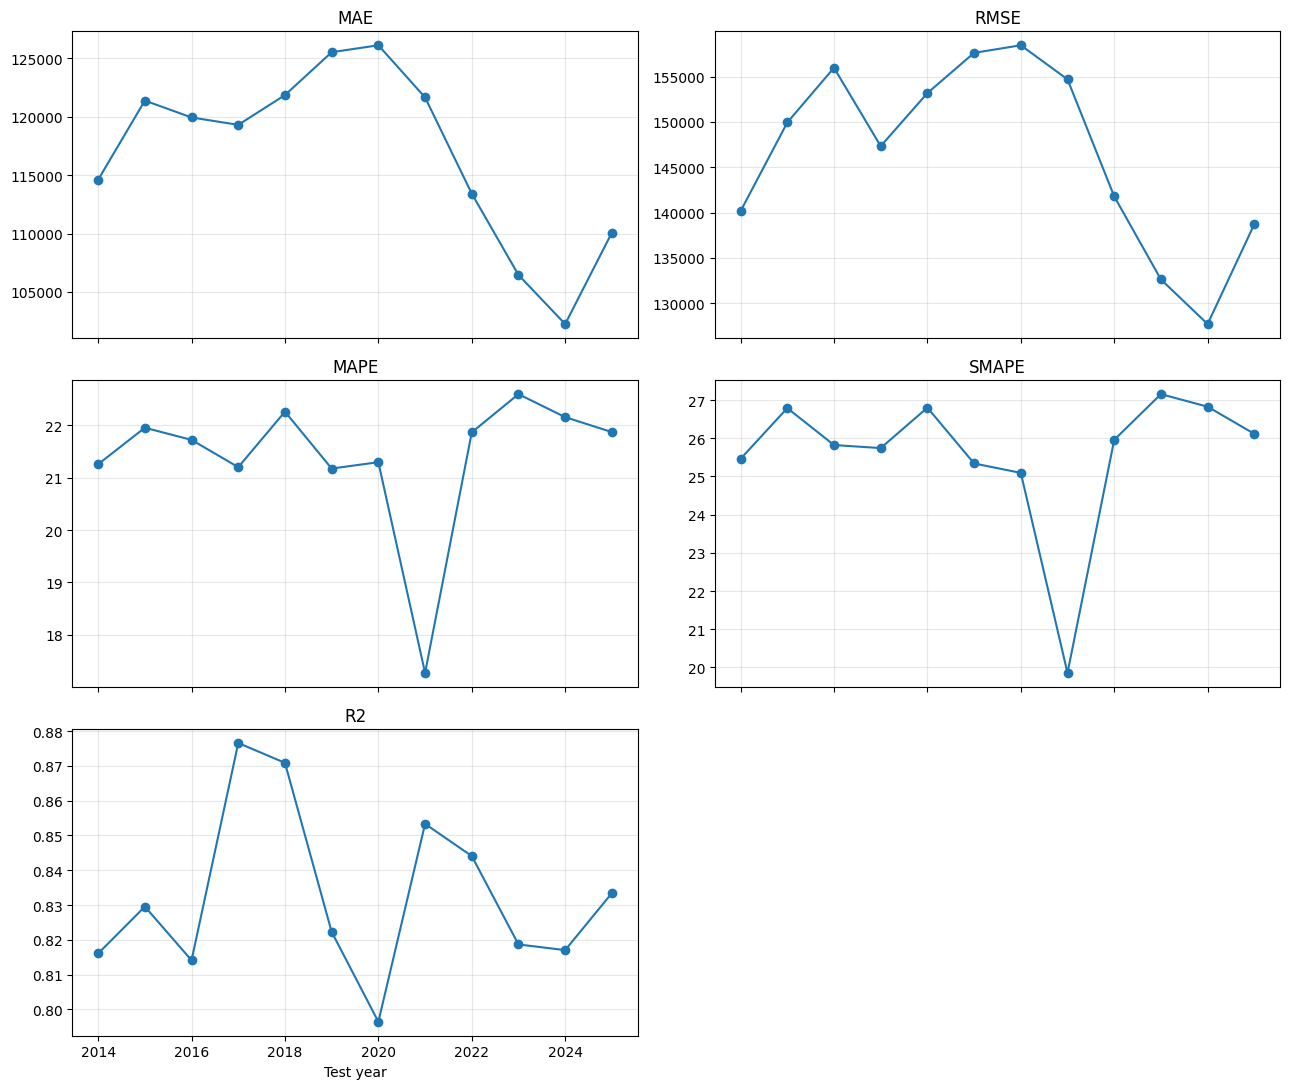

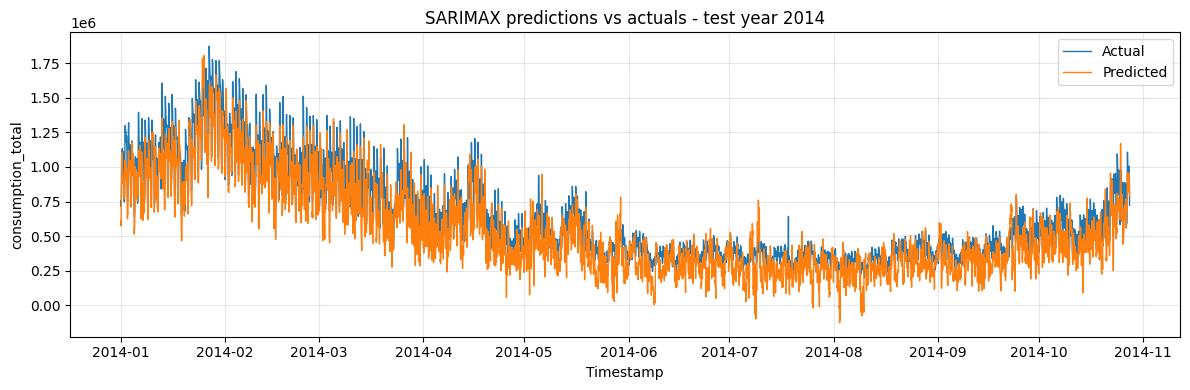

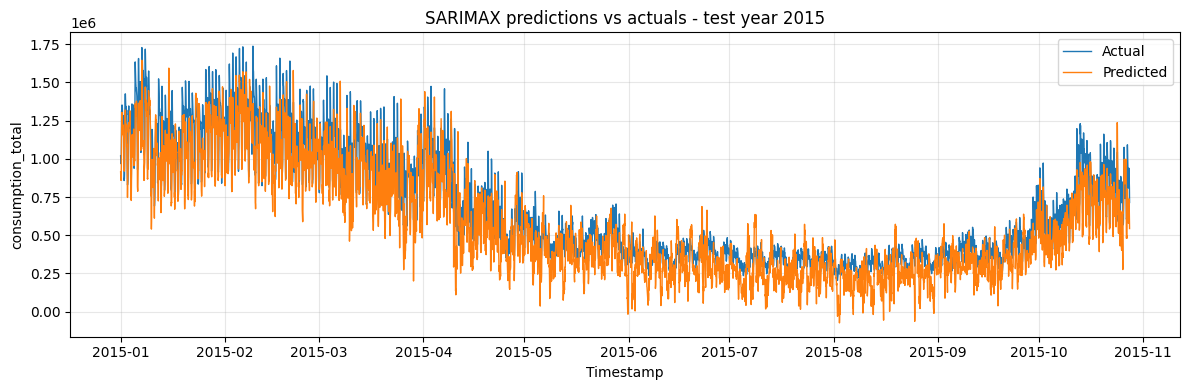

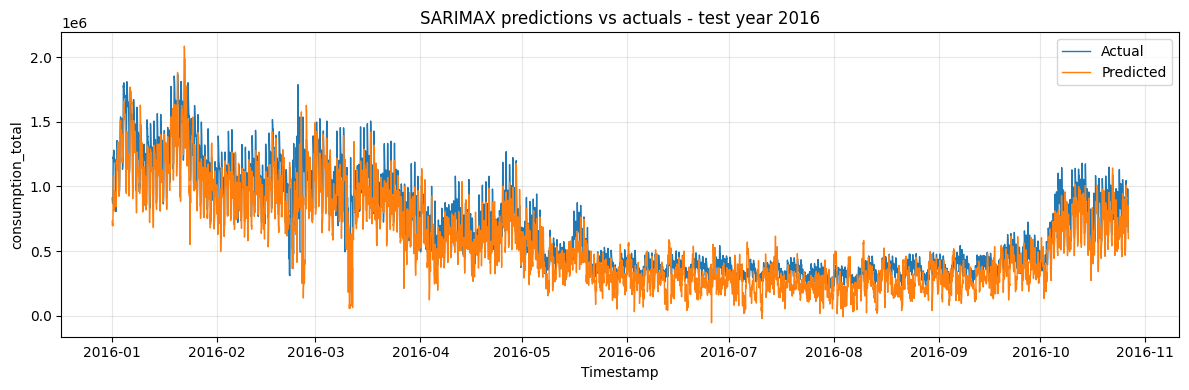

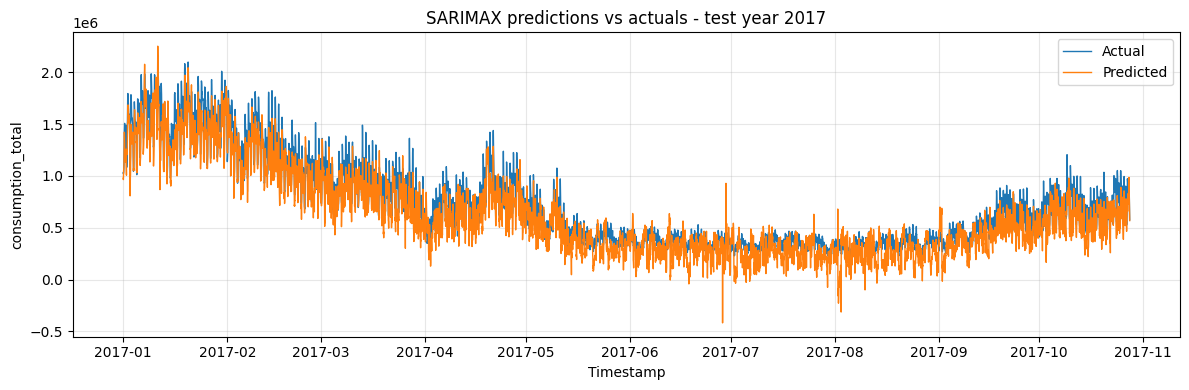

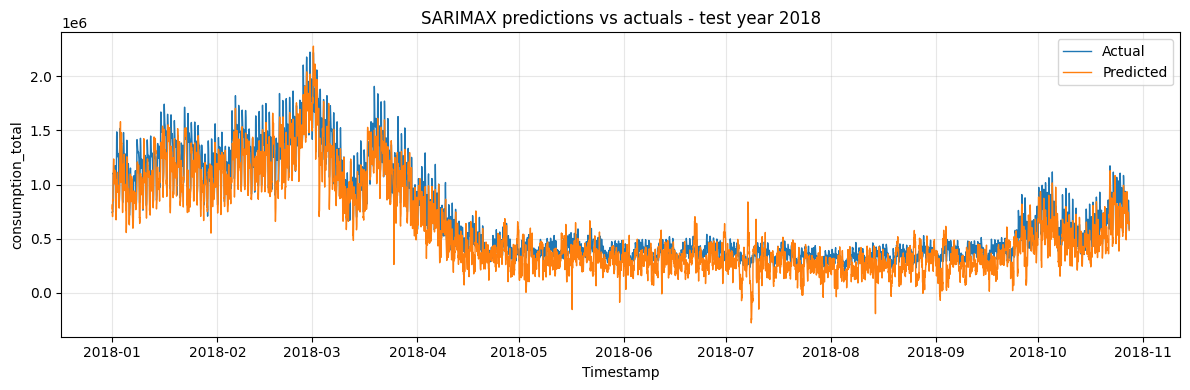

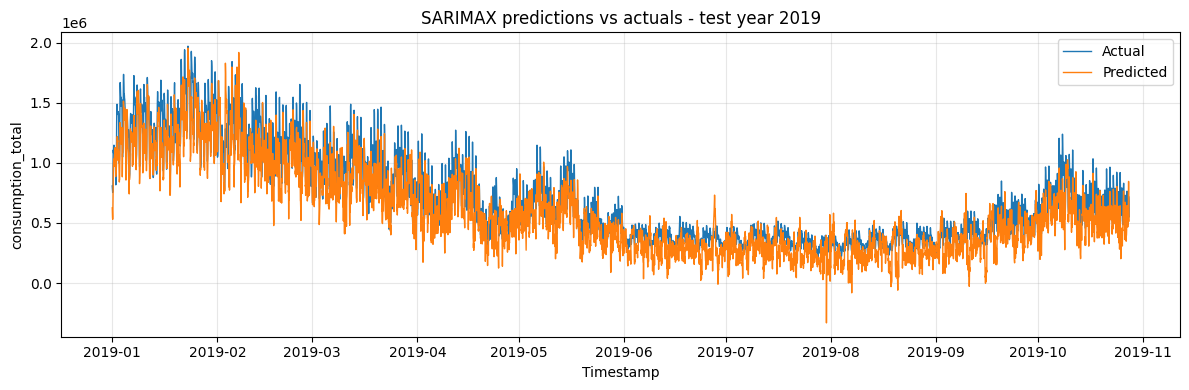

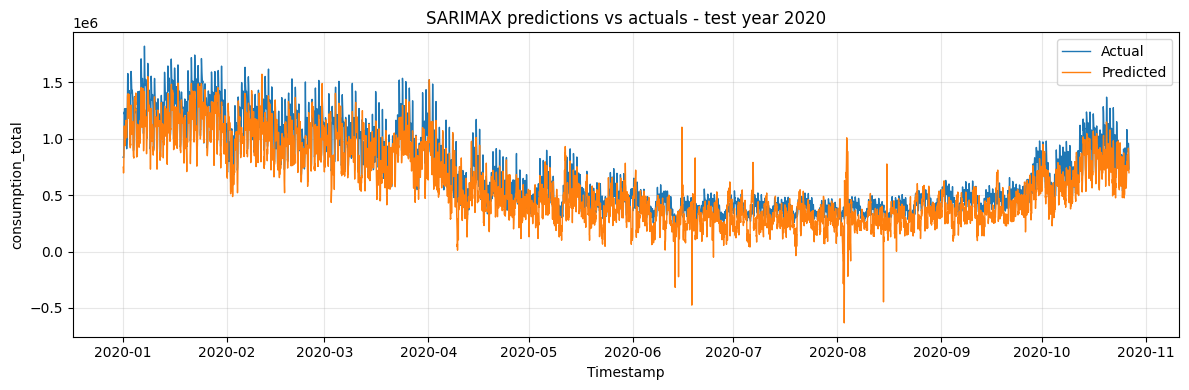

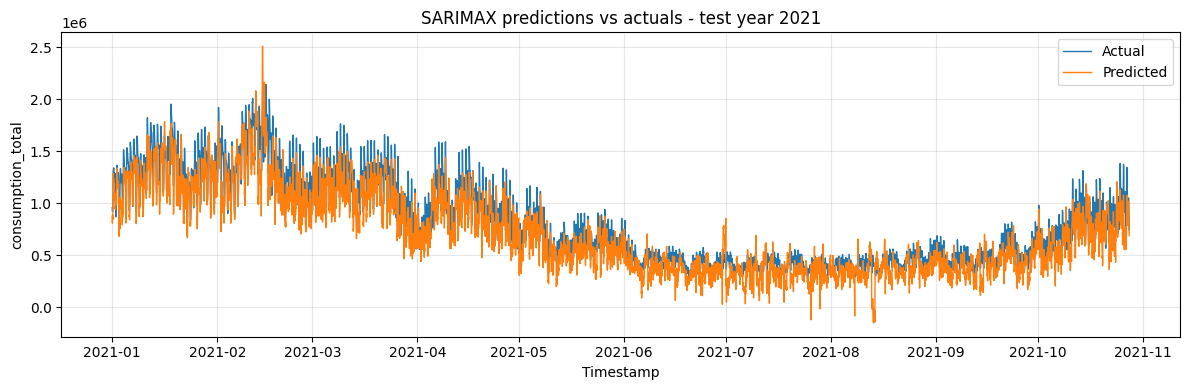

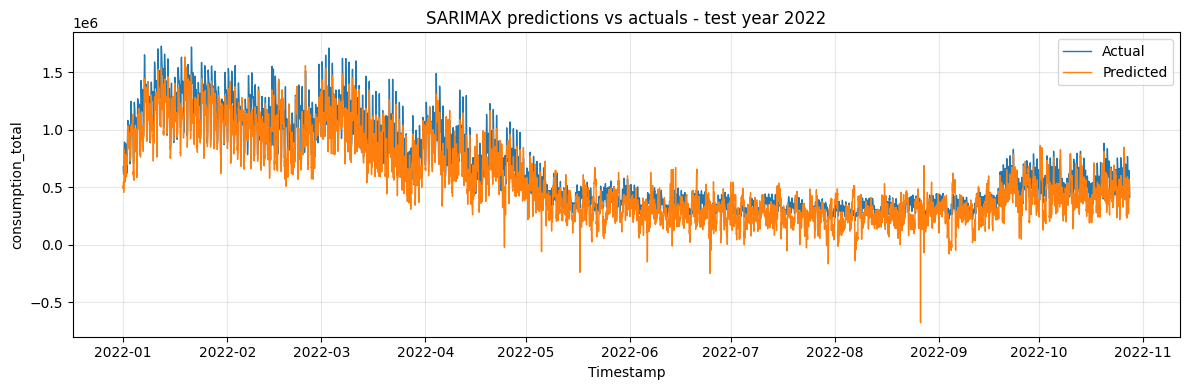

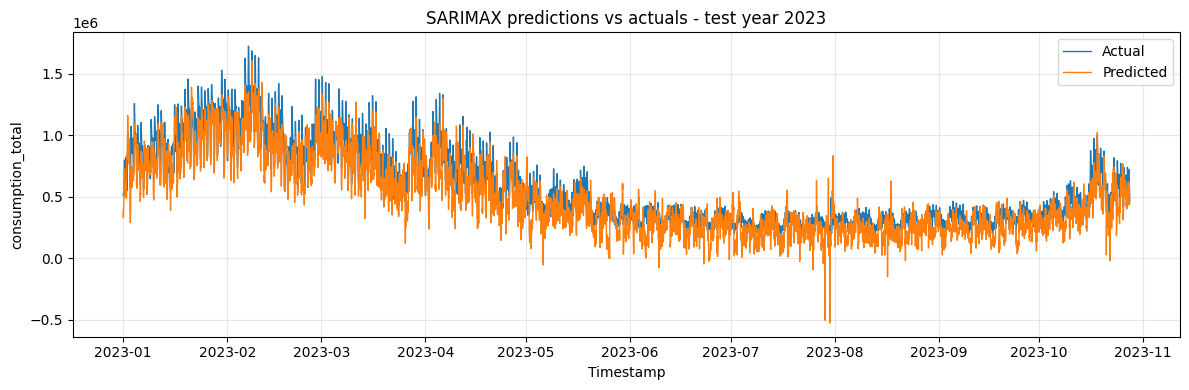

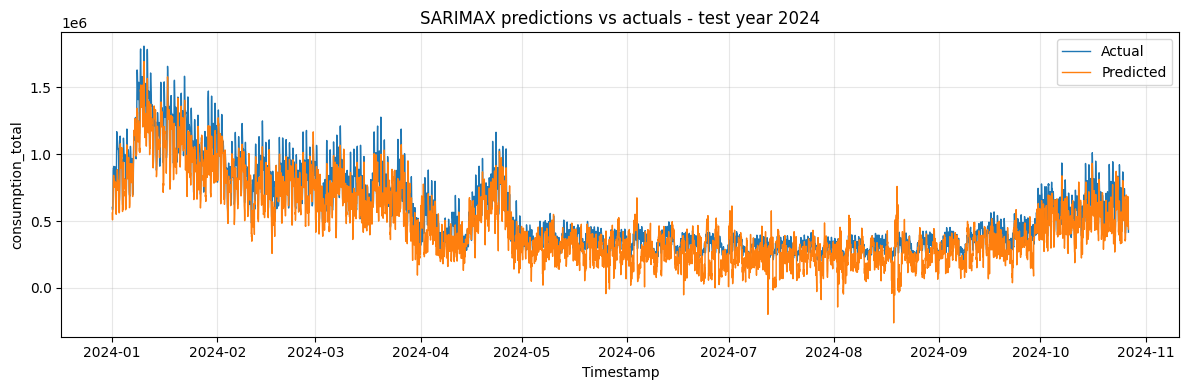

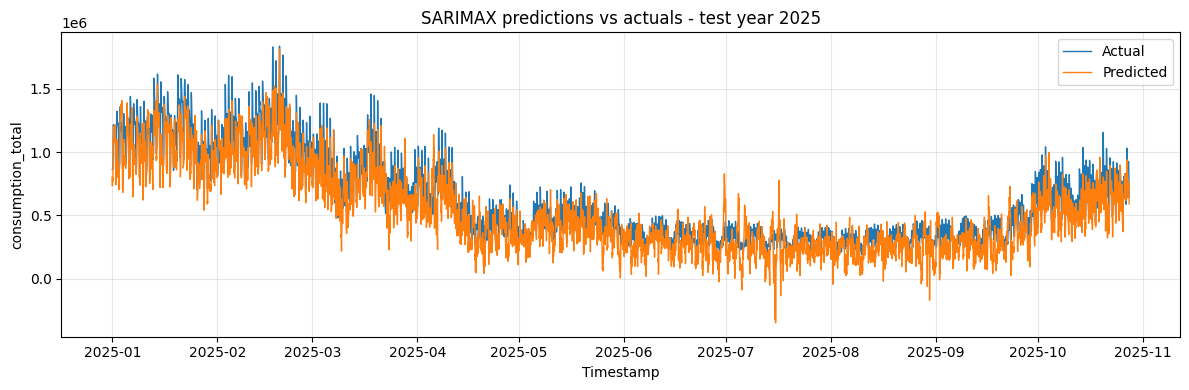

In [7]:
# Cross-fold metric trends
fig, axes = plt.subplots(3, 2, figsize=(13, 11), sharex=True)
metric_names = ["mae", "rmse", "mape", "smape", "r2"]

for ax, metric in zip(axes.flatten(), metric_names):
    ax.plot(metrics_df["test_year"], metrics_df[metric], marker="o")
    ax.set_title(metric.upper())
    ax.grid(alpha=0.3)

axes[-1, -1].axis("off")
axes[-1, 0].set_xlabel("Test year")
plt.tight_layout()
plt.show()

# Per-fold prediction plots
for row in metrics_df.itertuples(index=False):
    test_year = int(row.test_year)
    fold_pred = predictions_df[predictions_df["test_year"] == test_year].copy()
    fold_pred["timestamp"] = pd.to_datetime(fold_pred["timestamp"])

    plt.figure(figsize=(12, 4))
    plt.plot(fold_pred["timestamp"], fold_pred["y_true"], label="Actual", linewidth=1.0)
    plt.plot(
        fold_pred["timestamp"], fold_pred["y_pred"], label="Predicted", linewidth=1.0
    )
    plt.title(f"SARIMAX predictions vs actuals - test year {test_year}")
    plt.xlabel("Timestamp")
    plt.ylabel(CONFIG.target_col)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [8]:
expected_years = list(range(2014, 2026))
found_years = metrics_df["test_year"].tolist()

assert (
    found_years == expected_years
), f"Expected test years {expected_years}, got {found_years}"
assert len(metrics_df) == 12, f"Expected 12 fold metrics rows, got {len(metrics_df)}"
assert (metrics_df["n_predictions"] > 0).all(), "Some folds produced zero predictions"

saved_pred_files = sorted(PREDICTIONS_DIR.glob("sarimax_predictions_*.csv"))
assert (
    len(saved_pred_files) == 12
), f"Expected 12 per-year prediction files, got {len(saved_pred_files)}"
assert metrics_path.exists(), "Missing fold metrics CSV"
assert predictions_path.exists(), "Missing all-fold predictions CSV"

print("All sanity checks passed.")
print(f"Per-year prediction files: {len(saved_pred_files)}")
print(f"Metrics summary path: {metrics_path}")
print(f"All predictions path: {predictions_path}")

All sanity checks passed.
Per-year prediction files: 12
Metrics summary path: /local_storage/users/sli0124/diplomovy-projekt/data/results/sarimax_stepup/sarimax_fold_metrics.csv
All predictions path: /local_storage/users/sli0124/diplomovy-projekt/data/results/sarimax_stepup/sarimax_predictions_all_folds.csv


In [9]:
# Quick smoke test on first fold using the fast profile settings.
smoke_fold = folds[0]
smoke_test_year = int(smoke_fold["test_year"])
smoke_train_path = Path(smoke_fold["train_path"])
smoke_test_path = Path(smoke_fold["test_path"])

y_train_smoke, x_train_smoke = load_fold_frame(smoke_train_path, CONFIG.target_col)
y_test_smoke, x_test_smoke = load_fold_frame(smoke_test_path, CONFIG.target_col)

smoke_selected_exog = select_exog_columns(x_train_smoke, x_test_smoke)
x_train_smoke = x_train_smoke[smoke_selected_exog]
x_test_smoke = x_test_smoke[smoke_selected_exog]

if (
    CONFIG.max_train_history_hours is not None
    and len(y_train_smoke) > CONFIG.max_train_history_hours
):
    y_train_smoke_fit = y_train_smoke.iloc[-CONFIG.max_train_history_hours :]
    x_train_smoke_fit = x_train_smoke.iloc[-CONFIG.max_train_history_hours :]
else:
    y_train_smoke_fit = y_train_smoke
    x_train_smoke_fit = x_train_smoke

x_train_smoke_scaled, x_test_smoke_scaled = scale_exog_by_train(
    x_train_smoke_fit, x_test_smoke
)
smoke_fit = fit_sarimax(y_train_smoke_fit, x_train_smoke_scaled)
smoke_pred = rolling_forecast(
    fitted_model=smoke_fit,
    y_test=y_test_smoke,
    x_test=x_test_smoke_scaled,
    prediction_length=CONFIG.prediction_length,
    stride=CONFIG.stride,
    max_origins=CONFIG.max_origins_per_fold,
)

smoke_metrics = compute_metrics(
    smoke_pred["y_true"].to_numpy(dtype=float),
    smoke_pred["y_pred"].to_numpy(dtype=float),
)
print(f"smoke fold test_year={smoke_test_year}")
print(f"smoke selected exog ({len(smoke_selected_exog)}): {smoke_selected_exog}")
print("smoke metrics:", smoke_metrics)
print("first 5 preds:")
smoke_pred.head()

smoke fold test_year=2014
smoke selected exog (24): ['year', 'month', 'day', 'hour', 'day_of_week', 'holiday', 'before_holiday', 'temperature_2m', 'relative_humidity_2m', 'pressure_msl', 'surface_pressure', 'dew_point_2m', 'cloud_cover', 'wind_speed_10m', 'wind_direction_10m', 'apparent_temperature', 'wind_gusts_10m', 'precipitation', 'snowfall', 'snow_depth', 'traded_volume_mwh', 'weighted_avg_price_eur_mwh', 'min_price_eur_mwh', 'max_price_eur_mwh']
smoke metrics: {'mae': 114602.54336734583, 'rmse': 140155.28764237568, 'mape': 21.256385696396364, 'smape': 25.461230886738505, 'r2': 0.8160590546839943}
first 5 preds:


,timestamp,origin_timestamp,y_true,y_pred
0,2014-01-01 00:00:00,2014-01-01,752000.0,608050.630694
1,2014-01-01 01:00:00,2014-01-01,739884.0,585216.292876
2,2014-01-01 02:00:00,2014-01-01,736633.0,573392.578880
3,2014-01-01 03:00:00,2014-01-01,714643.0,636229.746464
4,2014-01-01 04:00:00,2014-01-01,718794.0,653949.971223
